## Importamos librerias

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

## Carga y lectura de dataset

In [5]:
df = pd.read_csv("ad_viz_plotval_data.csv")
df.head()

,Date,Source,Site ID,POC,Daily Max 1-hour SO2 Concentration,Units,Daily AQI Value,Local Site Name,Daily Obs Count,Percent Complete,...,AQS Parameter Description,Method Code,CBSA Code,CBSA Name,State FIPS Code,State,County FIPS Code,County,Site Latitude,Site Longitude
0,01/01/2022,AQS,60270002,1,0.2,ppb,0,WMRC/NCORE,24,100.0,...,Sulfur dioxide,560,13860,"Bishop, CA",6,California,27,Inyo,37.360684,-118.330783
1,01/02/2022,AQS,60270002,1,0.2,ppb,0,WMRC/NCORE,22,92.0,...,Sulfur dioxide,560,13860,"Bishop, CA",6,California,27,Inyo,37.360684,-118.330783
2,01/03/2022,AQS,60270002,1,0.2,ppb,0,WMRC/NCORE,24,100.0,...,Sulfur dioxide,560,13860,"Bishop, CA",6,California,27,Inyo,37.360684,-118.330783
3,01/04/2022,AQS,60270002,1,0.2,ppb,0,WMRC/NCORE,24,100.0,...,Sulfur dioxide,560,13860,"Bishop, CA",6,California,27,Inyo,37.360684,-118.330783
4,01/05/2022,AQS,60270002,1,0.2,ppb,0,WMRC/NCORE,22,92.0,...,Sulfur dioxide,560,13860,"Bishop, CA",6,California,27,Inyo,37.360684,-118.330783


## Información general de los datos

In [6]:
df.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 361 entries, 0 to 360
Data columns (total 21 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Date                                361 non-null    object 
 1   Source                              361 non-null    object 
 2   Site ID                             361 non-null    int64  
 3   POC                                 361 non-null    int64  
 4   Daily Max 1-hour SO2 Concentration  361 non-null    float64
 5   Units                               361 non-null    object 
 6   Daily AQI Value                     361 non-null    int64  
 7   Local Site Name                     361 non-null    object 
 8   Daily Obs Count                     361 non-null    int64  
 9   Percent Complete                    361 non-null    float64
 10  AQS Parameter Code                  361 non-null    int64  
 11  AQS Parameter Description           361 non-n

## Resumen estadístico

In [7]:
df.describe().round(1)

,Site ID,POC,Daily Max 1-hour SO2 Concentration,Daily AQI Value,Daily Obs Count,Percent Complete,AQS Parameter Code,Method Code,CBSA Code,State FIPS Code,County FIPS Code,Site Latitude,Site Longitude
count,361.0,361.0,361.0,361.0,361.0,361.0,361.0,361.0,361.0,361.0,361.0,361.0,361.0
mean,60270002.0,1.0,0.2,0.0,23.3,97.3,42401.0,560.0,13860.0,6.0,27.0,37.4,-118.3
std,0.0,0.0,0.1,0.0,1.0,3.9,0.0,0.0,0.0,0.0,0.0,0.0,0.0
min,60270002.0,1.0,0.2,0.0,20.0,83.0,42401.0,560.0,13860.0,6.0,27.0,37.4,-118.3
25%,60270002.0,1.0,0.2,0.0,22.0,92.0,42401.0,560.0,13860.0,6.0,27.0,37.4,-118.3
50%,60270002.0,1.0,0.2,0.0,24.0,100.0,42401.0,560.0,13860.0,6.0,27.0,37.4,-118.3
75%,60270002.0,1.0,0.3,0.0,24.0,100.0,42401.0,560.0,13860.0,6.0,27.0,37.4,-118.3
max,60270002.0,1.0,0.6,0.0,24.0,100.0,42401.0,560.0,13860.0,6.0,27.0,37.4,-118.3


## Nombres de las variables

In [8]:
df.columns

Index(['Date', 'Source', 'Site ID', 'POC',
       'Daily Max 1-hour SO2 Concentration', 'Units', 'Daily AQI Value',
       'Local Site Name', 'Daily Obs Count', 'Percent Complete',
       'AQS Parameter Code', 'AQS Parameter Description', 'Method Code',
       'CBSA Code', 'CBSA Name', 'State FIPS Code', 'State',
       'County FIPS Code', 'County', 'Site Latitude', 'Site Longitude'],
      dtype='object')

## Matriz de correlación visual

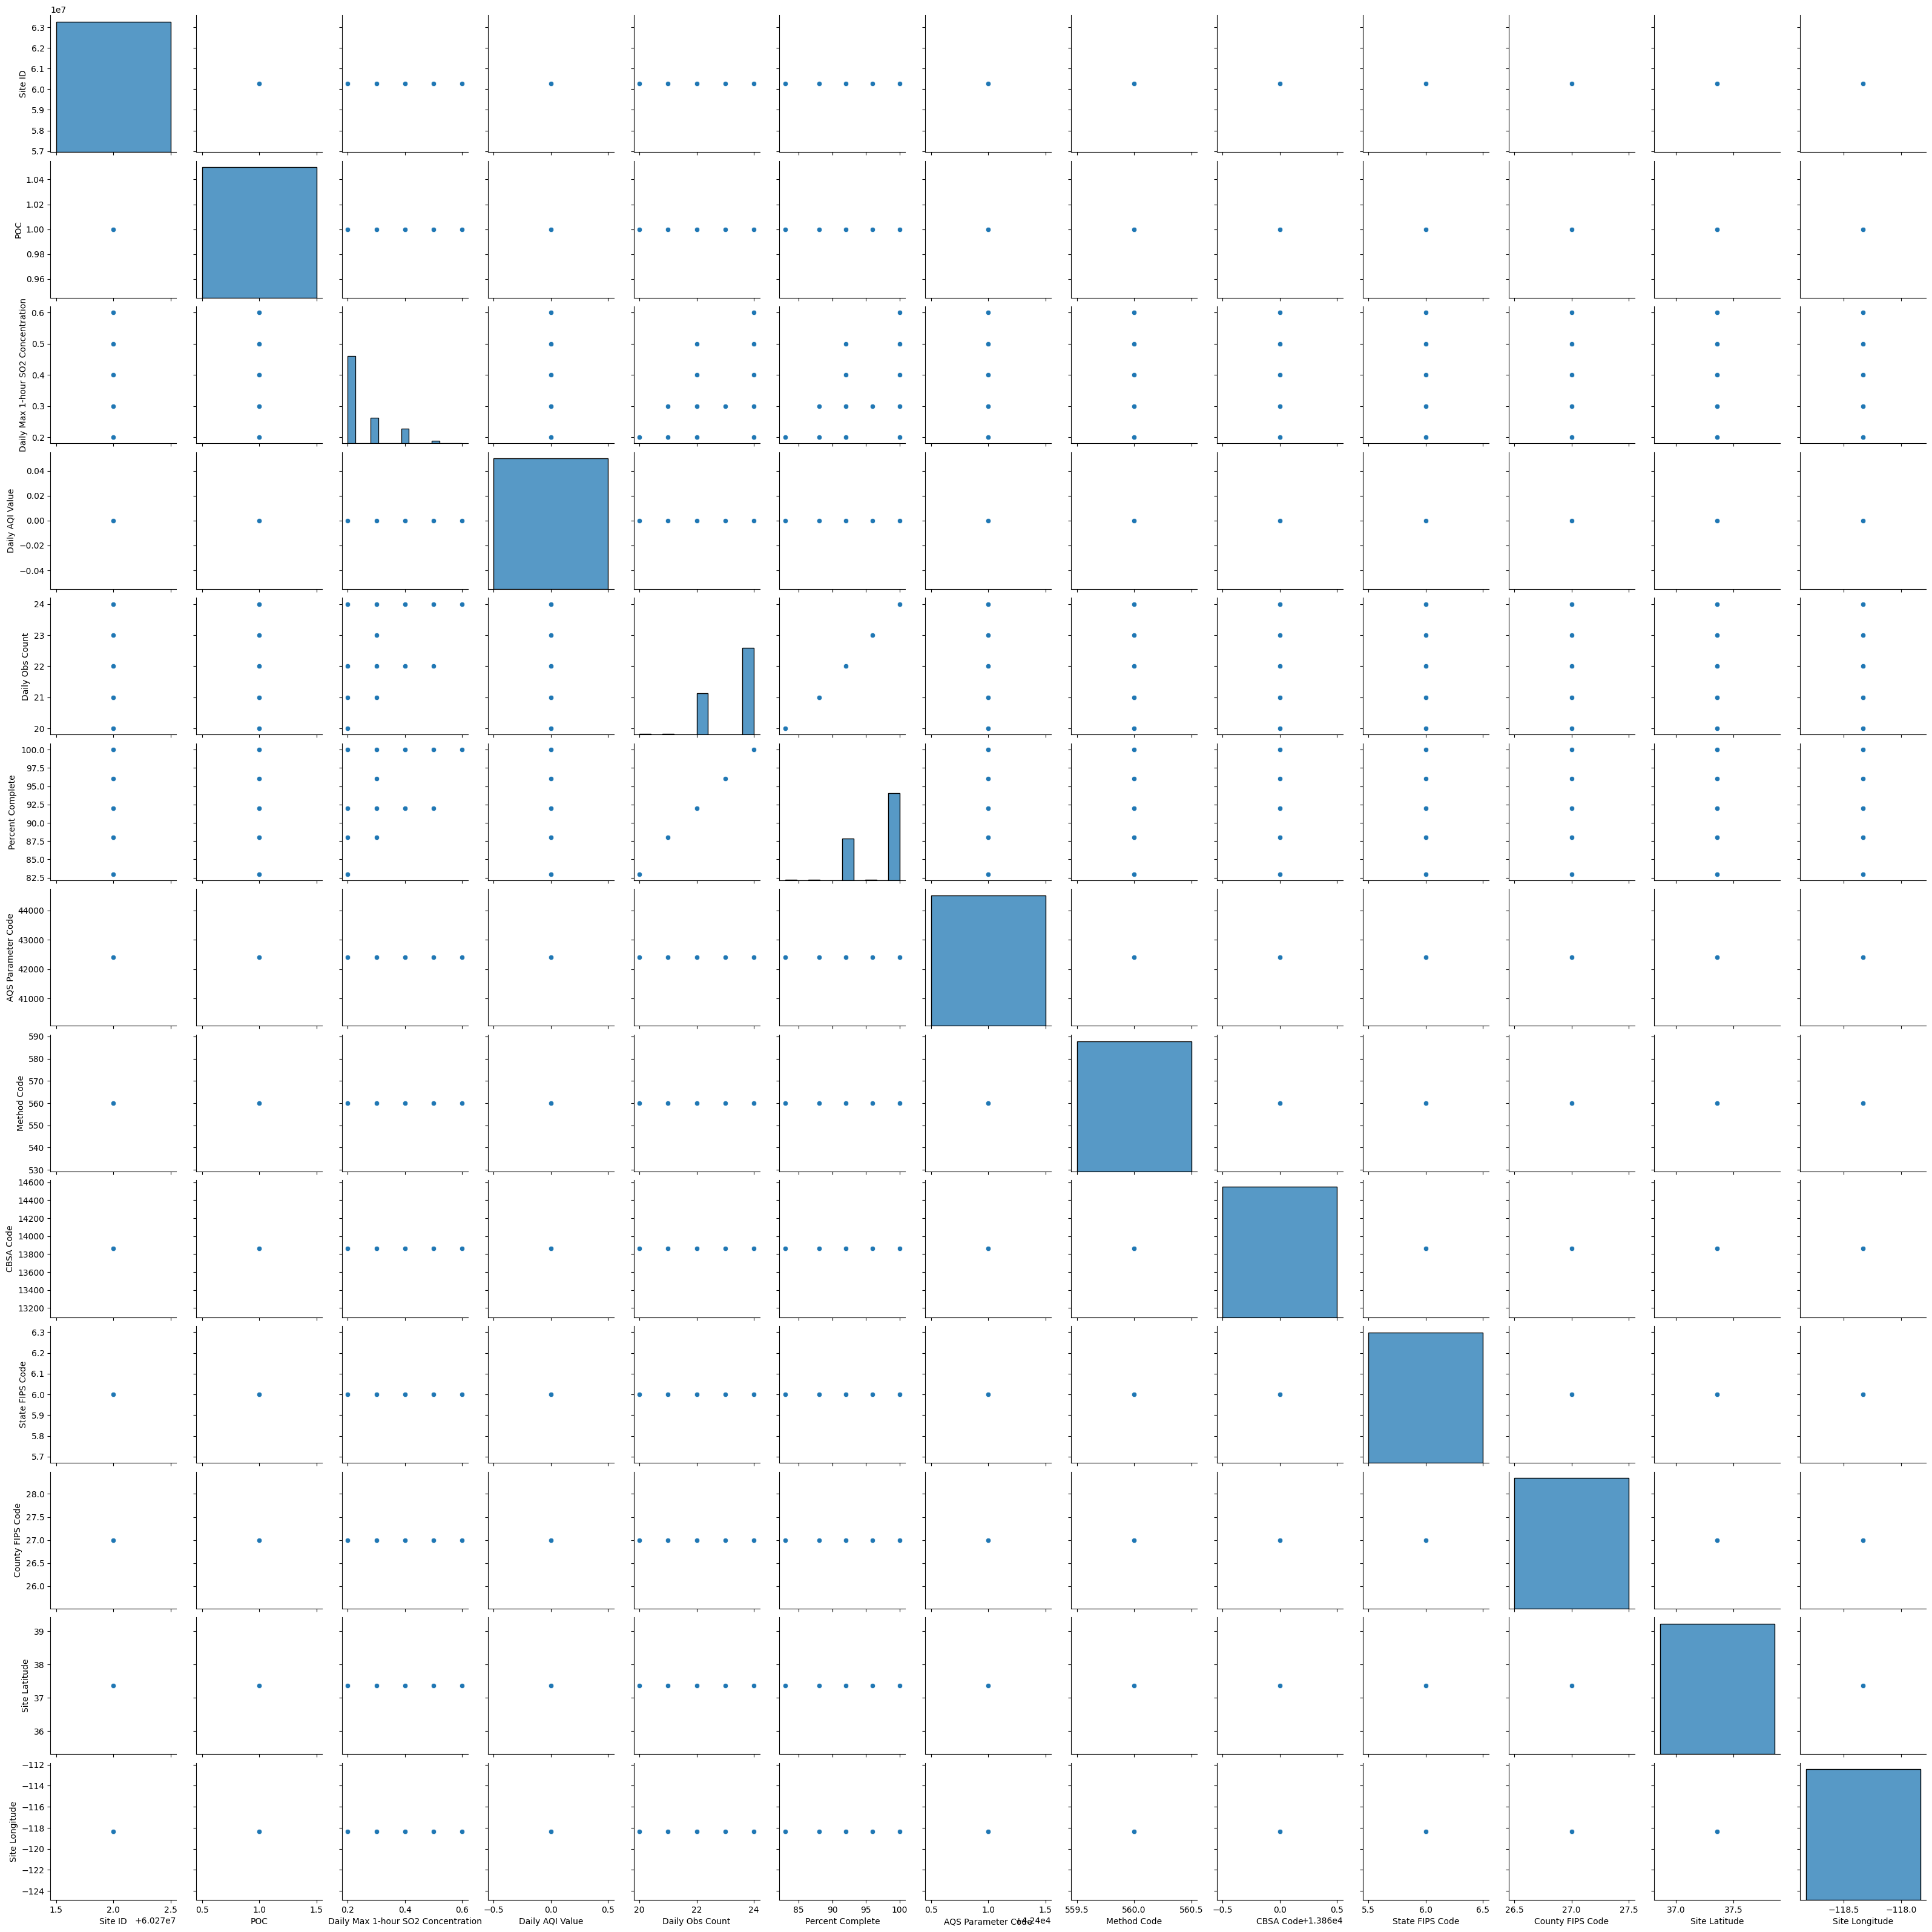

In [9]:
sns.pairplot(df)

## Preparación datos para la Regresión Lineal

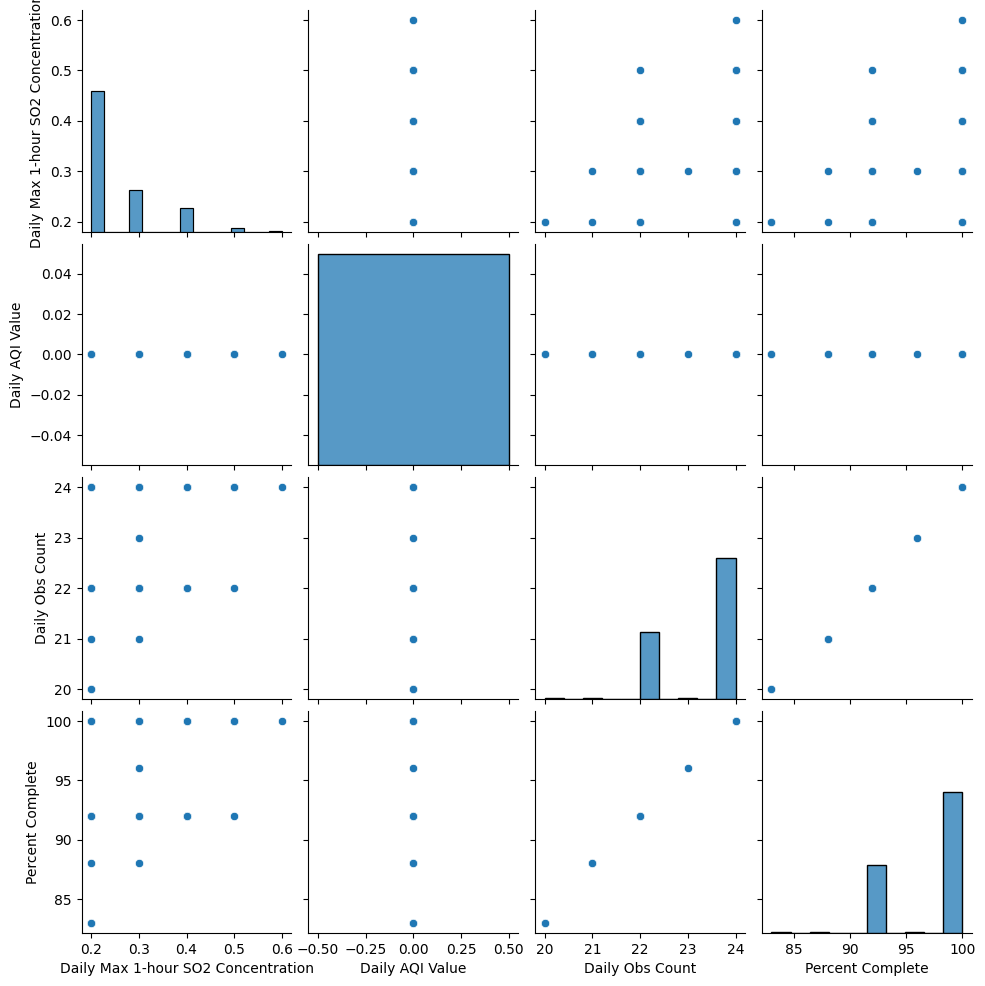

In [12]:
# Seleccionamos variables numéricas representativas de la calidad del aire
columnas_numericas = ['Daily Max 1-hour SO2 Concentration', 'Daily AQI Value', 'Daily Obs Count', 'Percent Complete']
sns.pairplot(df[columnas_numericas])

## Histograma

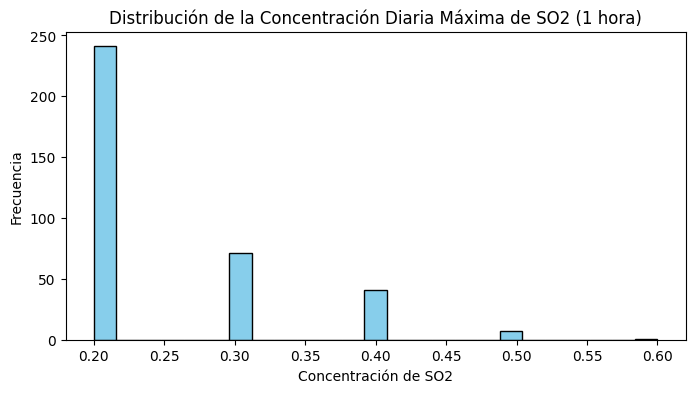

In [18]:
ax = df["Daily Max 1-hour SO2 Concentration"].plot.hist(bins=25, figsize=(8,4), color='skyblue', edgecolor='black')

plt.title("Distribución de la Concentración Diaria Máxima de SO2 (1 hora)")
plt.xlabel("Concentración de SO2")
plt.ylabel("Frecuencia")
plt.show()

## Entrenamiento del modelo de Regresión

In [14]:
from sklearn.metrics import mean_squared_error, r2_score

In [15]:
X = df[['Daily Max 1-hour SO2 Concentration']]
y = df['Daily AQI Value']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

modelo = LinearRegression()
modelo.fit(X_train, y_train)

y_pred = modelo.predict(X_test)
print(f"Coeficiente de regresión: {modelo.coef_[0]:.4f}")
print(f"Intersección: {modelo.intercept_:.4f}")
print(f"Error Cuadrático Medio (MSE): {mean_squared_error(y_test, y_pred):.4f}")
print(f"R-cuadrado (R2 Score): {r2_score(y_test, y_pred):.4f}")

Coeficiente de regresión: -0.0000
Intersección: 0.0000
Error Cuadrático Medio (MSE): 0.0000
R-cuadrado (R2 Score): 1.0000


## Visualización de la Regresíon

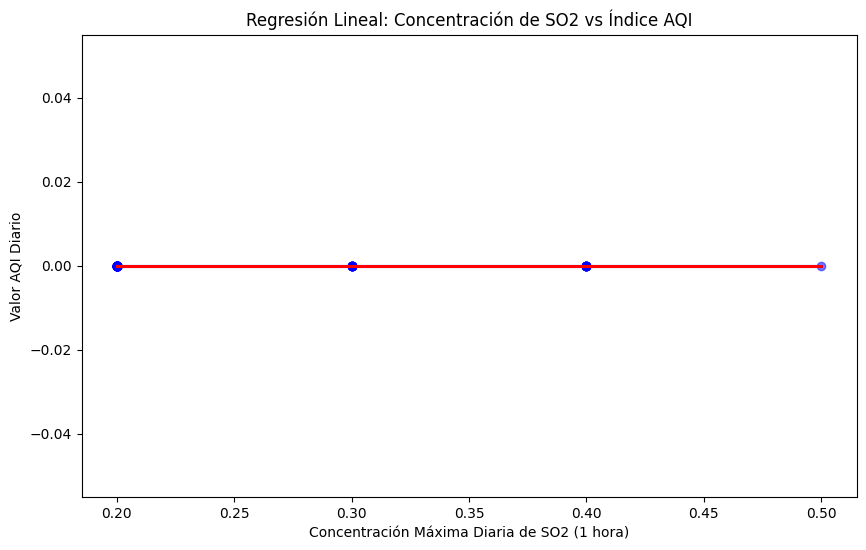

In [16]:
plt.figure(figsize=(10, 6))
sns.regplot(x=X_test['Daily Max 1-hour SO2 Concentration'], y=y_test, scatter_kws={'alpha':0.5}, color='blue')
plt.plot(X_test, y_pred, color='red', linewidth=2)
plt.title("Regresión Lineal: Concentración de SO2 vs Índice AQI")
plt.xlabel("Concentración Máxima Diaria de SO2 (1 hora)")
plt.ylabel("Valor AQI Diario")
plt.show()

## Grafico de densidad y mapa de calor

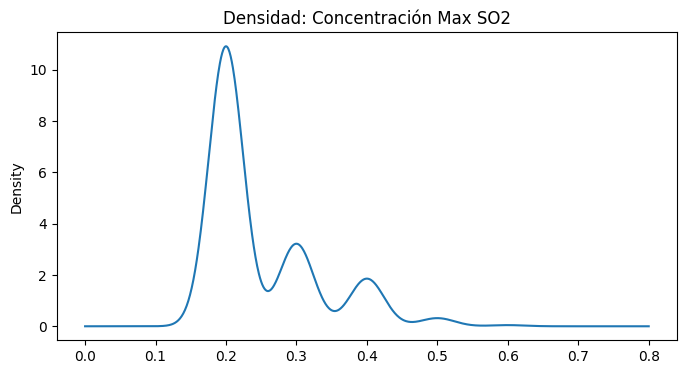

,Site ID,POC,Daily Max 1-hour SO2 Concentration,Daily AQI Value,Daily Obs Count,Percent Complete,AQS Parameter Code,Method Code,CBSA Code,State FIPS Code,County FIPS Code,Site Latitude,Site Longitude
Site ID,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
POC,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Daily Max 1-hour SO2 Concentration,NaN,NaN,1.0000,NaN,0.0458,0.0465,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Daily AQI Value,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Daily Obs Count,NaN,NaN,0.0458,NaN,1.0000,0.9998,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Percent Complete,NaN,NaN,0.0465,NaN,0.9998,1.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AQS Parameter Code,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Method Code,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CBSA Code,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
State FIPS Code,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


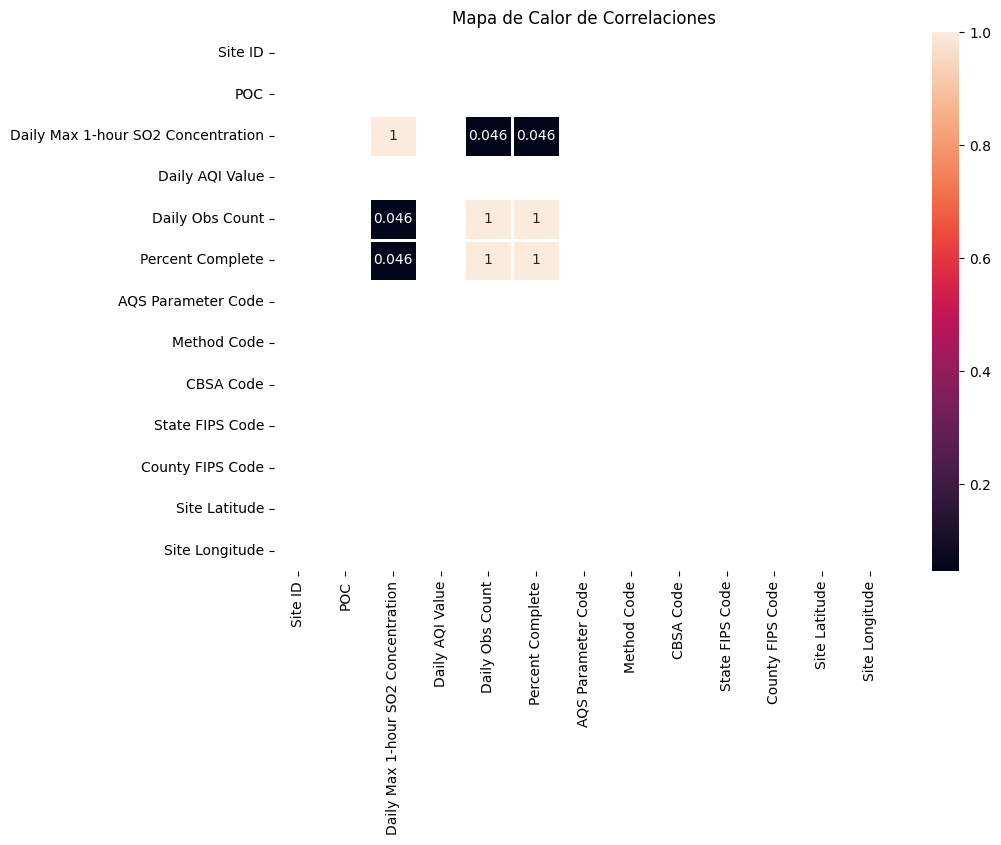

In [19]:
df["Daily Max 1-hour SO2 Concentration"].plot.density(figsize=(8,4))
plt.title("Densidad: Concentración Max SO2")
plt.show()

numeric_df = df.select_dtypes(include=[np.number])
display(numeric_df.corr().round(4))

plt.figure(figsize=(10,7))
sns.heatmap(numeric_df.corr(), annot=True, linewidths=2)
plt.title("Mapa de Calor de Correlaciones")
plt.show()

## Separación de Features(x) y Target (y)

In [20]:
cols = ['Site Latitude', 'Site Longitude', 'Percent Complete', 'Daily Obs Count', 'Daily Max 1-hour SO2 Concentration']
df_modelo = df[cols].dropna()

l_column = list(df_modelo.columns)
len_feature = len(l_column)

x = df_modelo[l_column[0:len_feature-1]]
y = df_modelo[l_column[len_feature-1]]
display(x.head())

,Site Latitude,Site Longitude,Percent Complete,Daily Obs Count
0,37.360684,-118.330783,100.0,24
1,37.360684,-118.330783,92.0,22
2,37.360684,-118.330783,100.0,24
3,37.360684,-118.330783,100.0,24
4,37.360684,-118.330783,92.0,22


## Cálculo del Error Estándar y Estadístico T

In [21]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

lm = LinearRegression()
lm.fit(x_train, y_train)

n = x_train.shape[0]
k = x_train.shape[1]
degrees_of_freedom = n - k - 1

train_pred = lm.predict(x_train)

train_error = np.square(train_pred - y_train)
sum_error = np.sum(train_error)

se = [0] * k

for i in range(k):
    r = sum_error / degrees_of_freedom
    r = r / np.sum(np.square(x_train.iloc[:, i] - x_train.iloc[:, i].mean()))
    se[i] = np.sqrt(r)

cdf = pd.DataFrame({'Standard Error': se})
cdf['Coefficients'] = lm.coef_
cdf['t-statistic'] = cdf['Coefficients'] / cdf['Standard Error']
display(cdf)

/tmp/ipykernel_3339/394793867.py:24: RuntimeWarning: divide by zero encountered in scalar divide
  r = r / np.sum(np.square(x_train.iloc[:, i] - x_train.iloc[:, i].mean()))


,Standard Error,Coefficients,t-statistic
0,inf,0.000000e+00,0.000000e+00
1,3.320643e+11,7.047314e-18,2.122274e-29
2,1.212092e-03,4.029091e-02,3.324080e+01
3,4.863680e-03,-1.580791e-01,-3.250195e+01


## Gráficos de dispersión múltiples

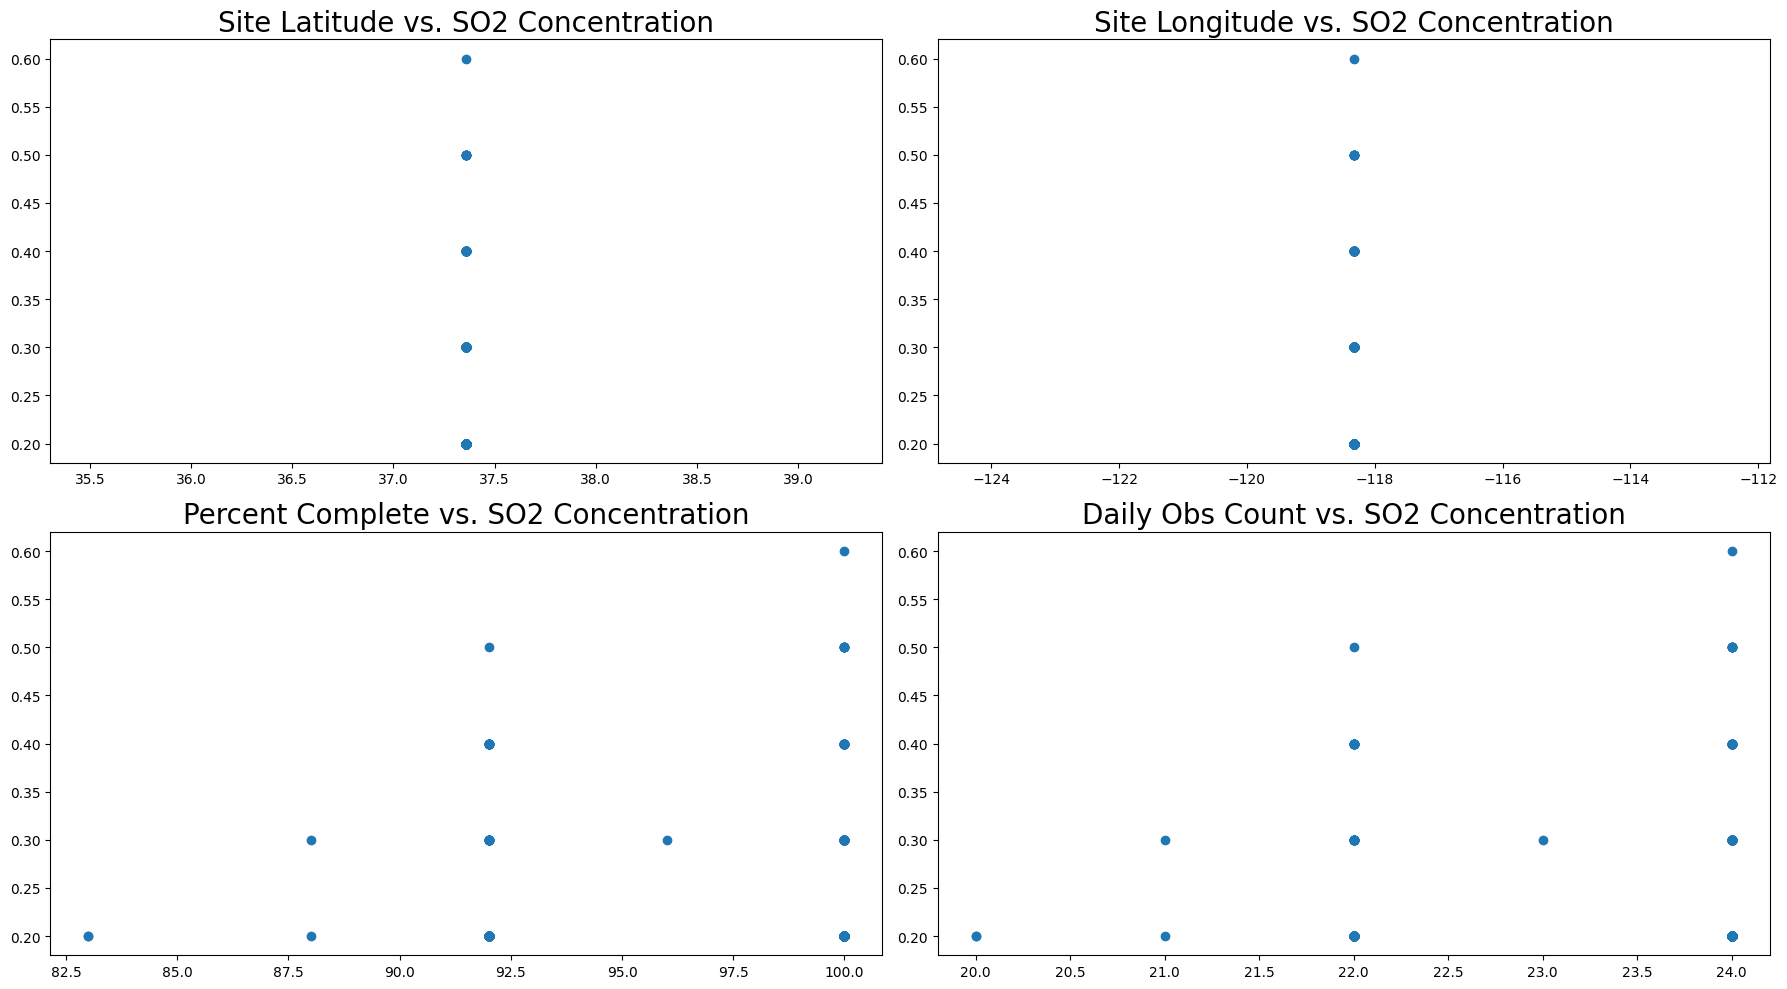

In [22]:
l = list(x.columns)
from matplotlib import gridspec
fig = plt.figure(figsize=(18, 10))
gs = gridspec.GridSpec(2, 2)

for i in range(4):
    ax = plt.subplot(gs[i])
    ax.scatter(x[l[i]], y)
    ax.set_title(l[i] + " vs. SO2 Concentration", fontdict={'fontsize': 20})

plt.tight_layout()
plt.show()

## Análisis de Residuos y Predicciones

Tipo del objeto predicho : <class 'numpy.ndarray'>
Tamaño del objeto predicho: (361,)


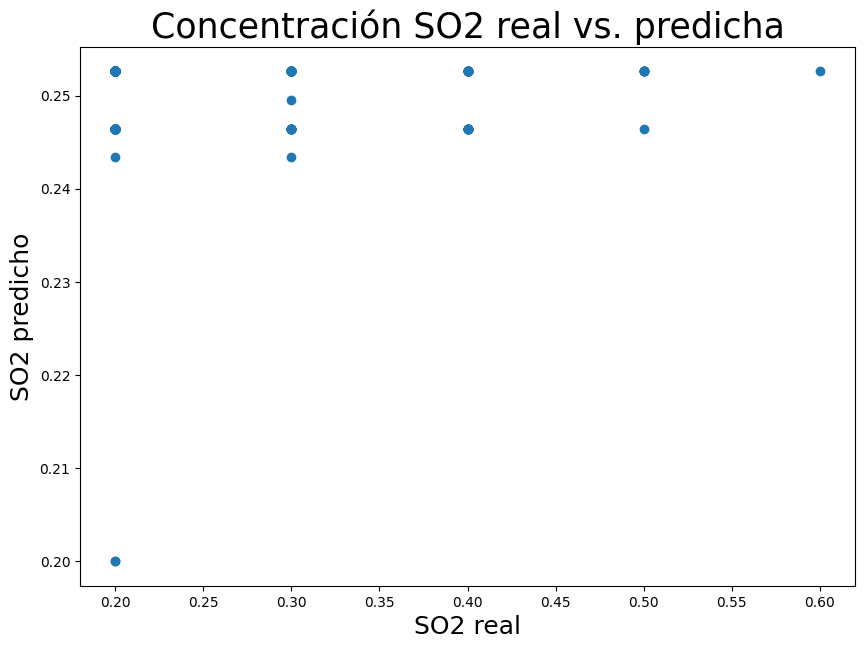

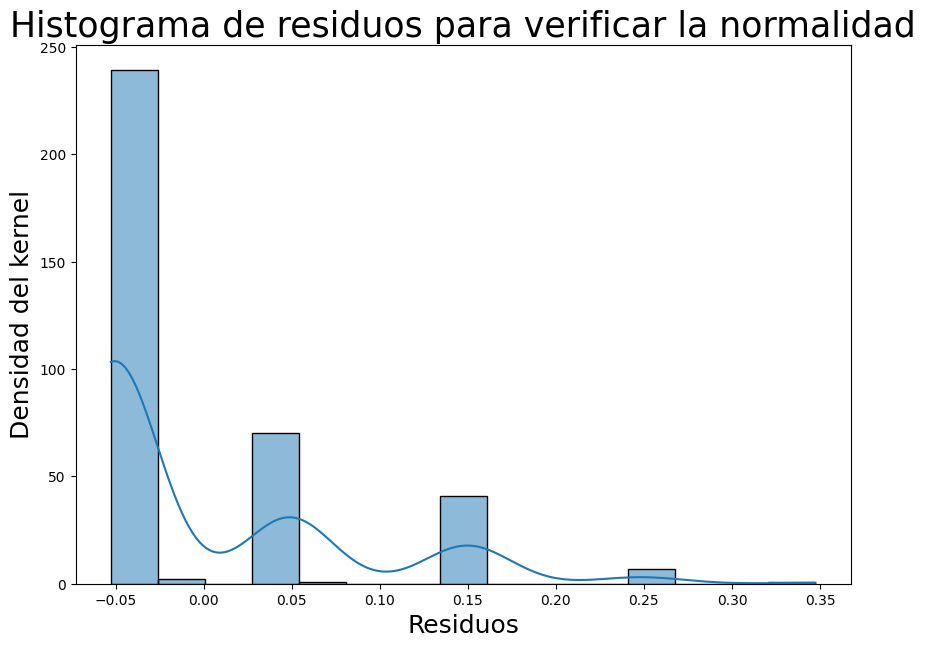

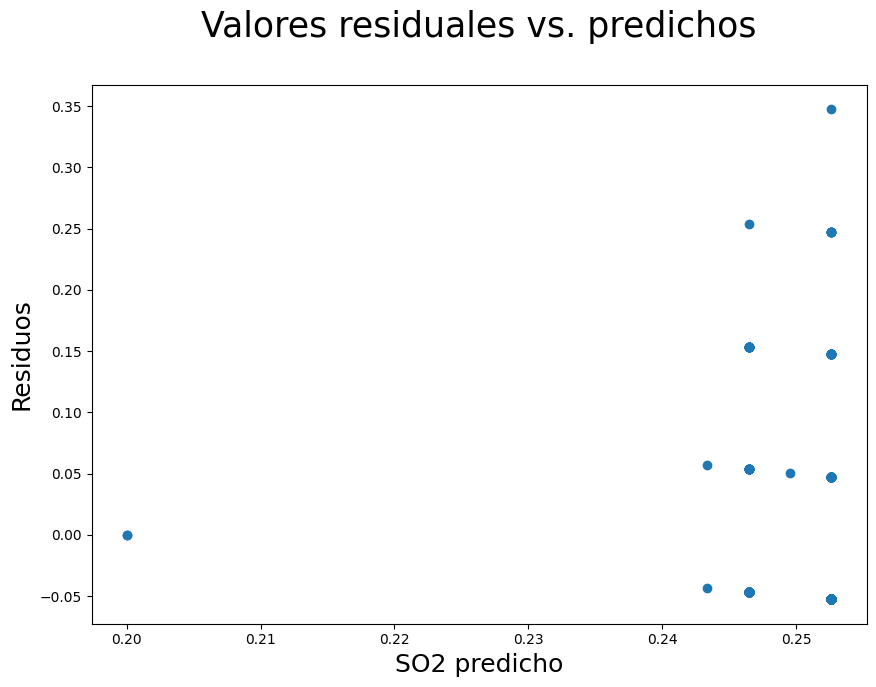

In [23]:
predictions = lm.predict(x)
print("Tipo del objeto predicho :", type(predictions))
print("Tamaño del objeto predicho:", predictions.shape)

plt.figure(figsize=(10, 7))
plt.title("Concentración SO2 real vs. predicha", fontsize=25)
plt.xlabel("SO2 real", fontsize=18)
plt.ylabel("SO2 predicho", fontsize=18)
plt.scatter(x=y, y=predictions)
plt.show()

plt.figure(figsize=(10, 7))
plt.title("Histograma de residuos para verificar la normalidad", fontsize=25)
plt.xlabel("Residuos", fontsize=18)
plt.ylabel("Densidad del kernel", fontsize=18)
sns.histplot((y - predictions), kde=True)
plt.show()

plt.figure(figsize=(10, 7))
plt.title("Valores residuales vs. predichos\n", fontsize=25)
plt.xlabel("SO2 predicho", fontsize=18)
plt.ylabel("Residuos", fontsize=18)
plt.scatter(x=predictions, y=y - predictions)
plt.show()

## Dataset Artificial

Coeficientes: [78.58638696 97.72361019 52.30606265  0.          0.          0.        ]


,X1,X2,X3,X4,X5,X6,y
0,0.883893,0.195865,0.357537,-2.343262,-1.084833,0.559696,109.512132
1,0.939469,-0.978481,0.503097,0.406414,0.323461,-0.493411,52.542242
2,-0.792017,-0.842368,-1.279503,0.245715,-0.044195,1.567633,-247.679018
3,1.051109,0.406368,-0.168646,-3.189703,1.120132,1.332778,98.678111
4,-0.243339,-0.130031,-0.109017,1.556186,0.128778,-2.066949,-55.286890
5,-0.885493,-1.104579,0.932866,2.059838,-0.934938,-1.612990,-94.821349
6,0.527070,-1.551101,0.329613,-1.136527,-0.338491,0.320971,-75.940071
7,-0.602308,1.544728,0.647034,0.593217,0.438024,1.357789,139.247064
8,1.204511,1.351796,0.493437,-2.704365,-0.555186,0.001509,246.470338
9,0.857094,1.481144,-0.219661,1.503398,-1.482385,-0.856164,204.709196


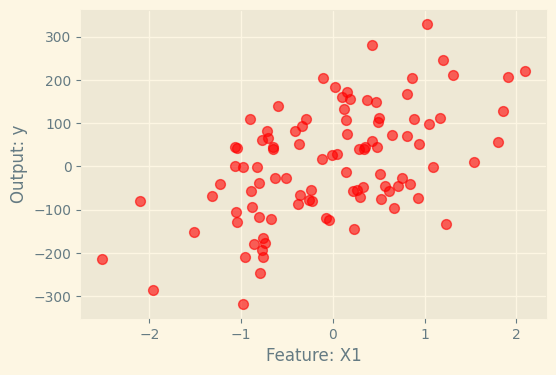

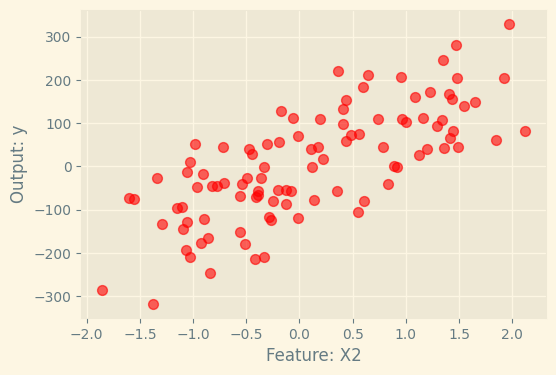

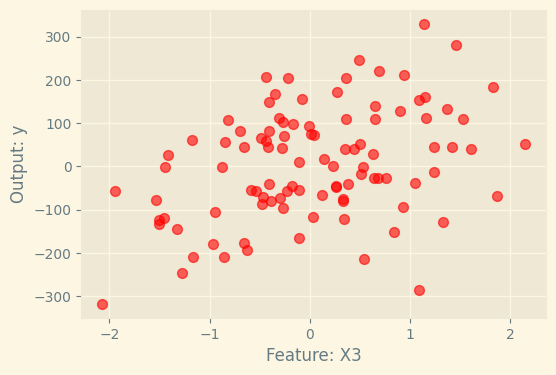

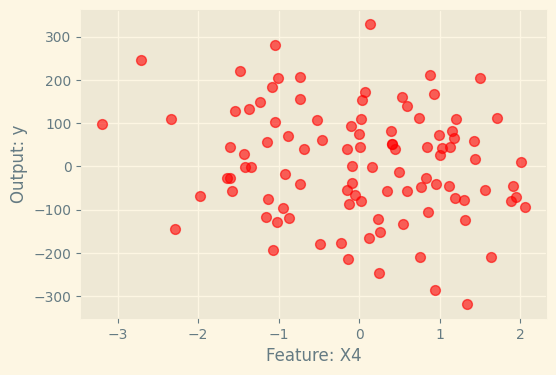

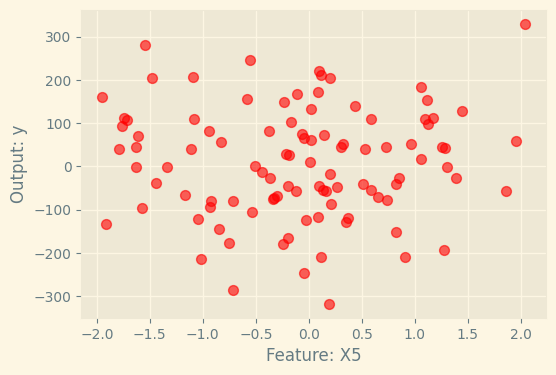

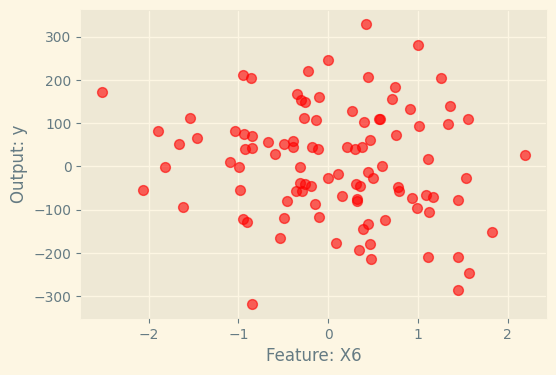

In [24]:
from sklearn.datasets import make_regression

n_samples = 100
n_features = 6
n_informative = 3

X_art, y_art, coef = make_regression(n_samples=n_samples, n_features=n_features, n_informative=n_informative,
                                     random_state=20, shuffle=False, noise=20, coef=True)
print("Coeficientes:", coef)

df1 = pd.DataFrame(data=X_art, columns=['X' + str(i) for i in range(1, n_features + 1)])
df2 = pd.DataFrame(data=y_art, columns=['y'])
df_artificial = pd.concat([df1, df2], axis=1)
display(df_artificial.head(10))

with plt.style.context(('Solarize_Light2')):
    for i, col in enumerate(df_artificial.columns[:-1]):
        plt.figure(figsize=(6, 4))
        plt.grid(True)
        plt.xlabel('Feature: ' + col, fontsize=12)
        plt.ylabel('Output: y', fontsize=12)
        plt.scatter(df_artificial[col], df_artificial['y'], c='red', s=50, alpha=0.6)
        plt.show()

## Modelo de Árboles y Resumen OLS (Datos Artificiales)

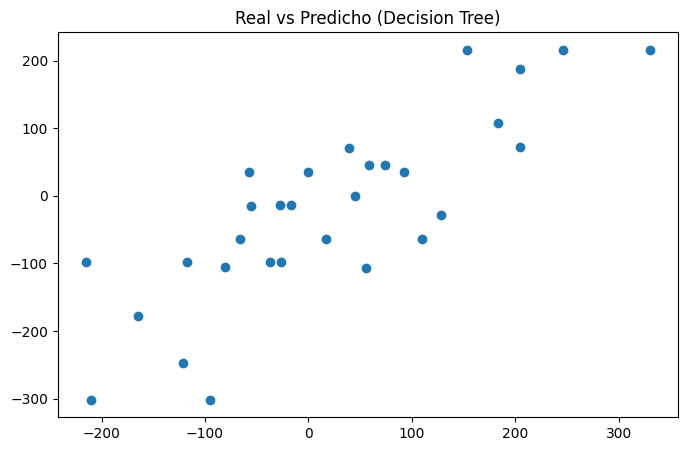

Mean square error (MSE): 7931.574768958281
Importancia relativa de las características:  [0.26900246 0.53730467 0.11075698 0.03758107 0.01219288 0.03316193]


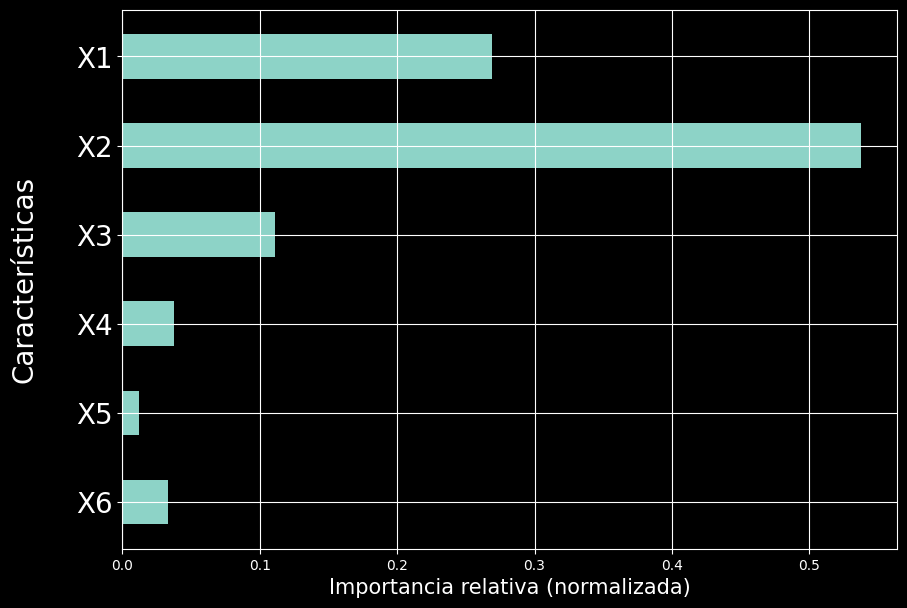

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.976
Model:                            OLS   Adj. R-squared:                  0.974
Method:                 Least Squares   F-statistic:                     628.6
Date:                Thu, 17 Sep 2026   Prob (F-statistic):           5.97e-73
Time:                        20:28:57   Log-Likelihood:                -440.25
No. Observations:                 100   AIC:                             894.5
Df Residuals:                      93   BIC:                             912.7
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -3.8565      2.087     -1.848      0.0

In [25]:
from sklearn import tree
from sklearn import metrics
import statsmodels.api as sm

X_train_art, X_test_art, y_train_art, y_test_art = train_test_split(X_art, y_art, test_size=0.3, random_state=123)

tree_model = tree.DecisionTreeRegressor(max_depth=5, random_state=10)
tree_model.fit(X_train_art, y_train_art)

test_pred_art = tree_model.predict(X_test_art)
plt.figure(figsize=(8,5))
plt.scatter(x=y_test_art, y=test_pred_art)
plt.title("Real vs Predicho (Decision Tree)")
plt.show()

print("Mean square error (MSE):", metrics.mean_squared_error(y_test_art, test_pred_art))
print("Importancia relativa de las características: ", tree_model.feature_importances_)

with plt.style.context('dark_background'):
    plt.figure(figsize=(10, 7))
    plt.grid(True)
    plt.yticks(range(n_features, 0, -1), df_artificial.columns[:-1], fontsize=20)
    plt.xlabel("Importancia relativa (normalizada)", fontsize=15)
    plt.ylabel("Características\n", fontsize=20)
    plt.barh(range(n_features, 0, -1), width=tree_model.feature_importances_, height=0.5)
    plt.show()

Xs = sm.add_constant(X_art)
stat_model = sm.OLS(y_art, Xs)
stat_result = stat_model.fit()
print(stat_result.summary())